**Sel 1: Import Library dan Cek Versi TensorFlow**

Impor semua library yang diperlukan. TensorFlow untuk model deep learning, Matplotlib/Seaborn untuk visualisasi, dan Scikit-learn untuk metrik evaluasi.

In [23]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("Semua library berhasil di-import.")
print("TensorFlow version:", tf.__version__)

Semua library berhasil di-import.
TensorFlow version: 2.20.0


**Sel 2: Mount Google Drive (jika dataset ada di Drive)**

Jika dataset disimpan di Google Drive, mounting akan membuatnya bisa diakses dari Colab

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Sel 3: Tentukan Path Dataset**

Sesuaikan dataset_path dengan lokasi folder dataset di lingkungan Colab. Dataset harus memiliki subfolder rock, paper, scissors.

In [25]:
dataset_path = "/content/drive/MyDrive/rockpaperscissors"

print(f"Path dataset: {dataset_path}")

Path dataset: /content/drive/MyDrive/rockpaperscissors


**Sel 4: ImageDataGenerator & Split Data**

- ImageDataGenerator membaca gambar dari folder, otomatis memberi label sesuai nama subfolder.
- rescale=1./255: Normalisasi piksel dari 0..255 menjadi 0..1.
- validation_split=0.2: 20% data digunakan sebagai validasi (tidak ikut pelatihan).
- flow_from_directory akan membaca gambar, resize ke 150x150, dan memberi label.

In [26]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training',
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
)

print("generator training & validasi.")

Found 1751 images belonging to 3 classes.
Found 437 images belonging to 3 classes.
generator training & validasi.


**Sel 5: Lihat Label Kelas**
Menampilkan urutan kelas yang dikenali. Nanti indeks 0 = paper, 1 = rock, 2 = scissors.

In [27]:
class_names = list(train_generator.class_indices.keys())
print("Label kelas:", train_generator.class_indices)
print("   Urutan kelas:", class_names)

Label kelas: {'paper': 0, 'rock': 1, 'scissors': 2}
   Urutan kelas: ['paper', 'rock', 'scissors']


**Sel 6: Arsitektur CNN**
- Conv2D: Lapisan konvolusi yang belajar mendeteksi fitur (misal tepi, sudut).
- MaxPooling2D: Mengecilkan dimensi gambar, mengambil nilai maksimum di area kecil.
- Flatten: Meratakan hasil pooling menjadi vektor agar bisa masuk ke Dense layer.
- Dense(512, 'relu'): Lapisan tersembunyi untuk belajar kombinasi fitur.
- Dense(3, 'softmax'): Lapisan output 3 neuron, menghasilkan probabilitas masing-masing kelas (jumlahnya 1).

In [28]:
model = Sequential([
    # Blok 1: Ekstraksi fitur dasar (tepi, warna)
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    # Blok 2: Fitur lebih kompleks (tekstur, bentuk)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Blok 3: Fitur tingkat tinggi
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Flatten: Ubah peta fitur 2D menjadi vektor 1D
    Flatten(),

    # Fully Connected (Dense) layer untuk klasifikasi
    Dense(512, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,203 (72.61 MB)

 Trainable params: 19,035,203 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

**Sel 7: Kompilasi Model**
- categorical_crossentropy: Fungsi loss untuk klasifikasi multi-kelas (label one-hot).
- adam: Optimizer adaptif yang menggabungkan keunggulan beberapa metode.
- metrics=['accuracy']: Kita ukur akurasi selama training.

In [29]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("Model berhasil di-compile.")

Model berhasil di-compile.


**Sel 8: Latih Model**
- Model akan belajar selama 10 epoch (1 epoch = lihat seluruh data training sekali).
- validation_data: Digunakan untuk mengevaluasi model setiap akhir epoch.
- history: Menyimpan nilai loss dan akurasi setiap epoch, untuk grafik.

In [30]:
print("\n=== Memulai pelatihan model ===\n")
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)
print("Pelatihan selesai")


=== Memulai pelatihan model ===

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 335s 6s/step - accuracy: 0.6882 - loss: 0.7565 - val_accuracy: 0.8856 - val_loss: 0.3565
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.9189 - loss: 0.2280 - val_accuracy: 0.9268 - val_loss: 0.1951
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9652 - loss: 0.0995 - val_accuracy: 0.9657 - val_loss: 0.1081
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9777 - loss: 0.0611 - val_accuracy: 0.9725 - val_loss: 0.1004
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.9914 - loss: 0.0293 - val_accuracy: 0.9542 - val_loss: 0.1593
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9886 - loss: 0.0364 - val_accuracy: 0.9657 - val_loss: 0.1182
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 0.9748 - val_loss: 0.0975
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.9989 - loss:

**Sel 9: Evaluasi Model pada Data Validasi**

Menghitung loss dan akurasi model pada data yang tidak digunakan saat training (validasi), sehingga bisa menilai kemampuan generalisasi.



In [31]:
val_loss, val_acc = model.evaluate(validation_generator)
print(f"\nValidation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 660ms/step - accuracy: 0.9748 - loss: 0.1331

Validation Loss    : 0.1331
Validation Accuracy: 0.9748 (97.48%)


**Sel 10: Prediksi & Contoh Probabilitas**

- .predict() menghasilkan probabilitas tiap kelas untuk semua gambar validasi.
- Ambil 5 sampel pertama, lihat probabilitasnya, dan label dengan probabilitas tertinggi.

In [32]:
predictions = model.predict(validation_generator)

print("Contoh probabilitas prediksi (5 sampel pertama):")
for i in range(5):
    pred_probs = predictions[i]
    pred_label = class_names[np.argmax(pred_probs)]
    prob_str = {class_names[j]: f"{pred_probs[j]:.4f}" for j in range(3)}
    print(f"  Sampel {i+1}: {prob_str} => Prediksi: {pred_label}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 496ms/step
Contoh probabilitas prediksi (5 sampel pertama):
  Sampel 1: {'paper': '1.0000', 'rock': '0.0000', 'scissors': '0.0000'} => Prediksi: paper
  Sampel 2: {'paper': '0.0000', 'rock': '0.0000', 'scissors': '1.0000'} => Prediksi: scissors
  Sampel 3: {'paper': '1.0000', 'rock': '0.0000', 'scissors': '0.0000'} => Prediksi: paper
  Sampel 4: {'paper': '0.9218', 'rock': '0.0000', 'scissors': '0.0782'} => Prediksi: paper
  Sampel 5: {'paper': '0.0000', 'rock': '0.0000', 'scissors': '1.0000'} => Prediksi: scissors


**Sel 11: Plot Grafik Akurasi & Loss**

Grafik kiri menunjukkan akurasi training vs validasi setiap epoch. Grafik kanan menunjukkan loss. Idealnya loss turun dan akurasi naik, serta validasi tidak jauh dari training (tidak overfitting).

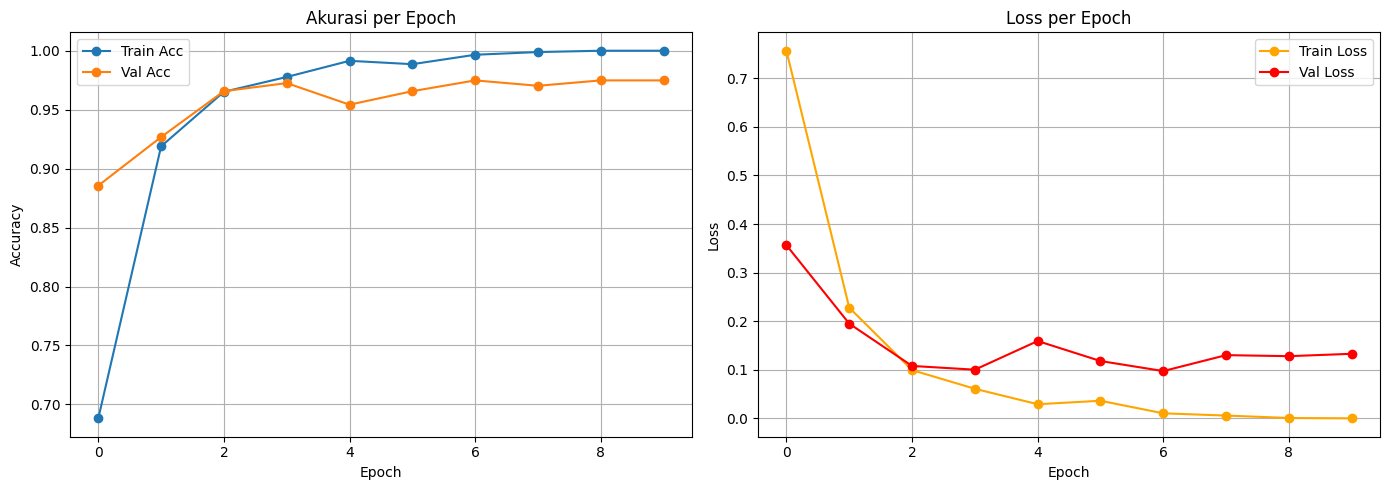

Grafik disimpan sebagai 'training_history.png'


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Akurasi
axes[0].plot(history.history['accuracy'], label='Train Acc', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Acc', marker='o')
axes[0].set_title('Akurasi per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', marker='o', color='orange')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='o', color='red')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("Grafik disimpan sebagai 'training_history.png'")

**Sel 12: Confusion Matrix & Classification Report**
- Confusion Matrix: Tabel yang menunjukkan jumlah prediksi benar (diagonal) dan salah (off-diagonal).
- Classification Report: Precision, recall, F1-score untuk tiap kelas.

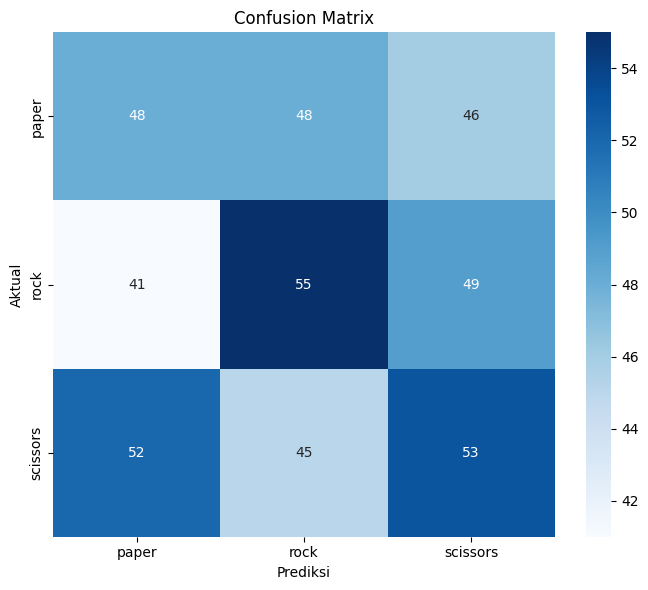


Classification Report:
              precision    recall  f1-score   support

       paper       0.34      0.34      0.34       142
        rock       0.37      0.38      0.38       145
    scissors       0.36      0.35      0.36       150

    accuracy                           0.36       437
   macro avg       0.36      0.36      0.36       437
weighted avg       0.36      0.36      0.36       437



In [34]:
validation_generator.reset()
y_true = validation_generator.classes
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

**Sel 13: Contoh Prediksi Gambar dari Batch**

Menampilkan 10 gambar dari batch validasi beserta label asli dan prediksi. Warna hijau jika benar, merah jika salah.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step


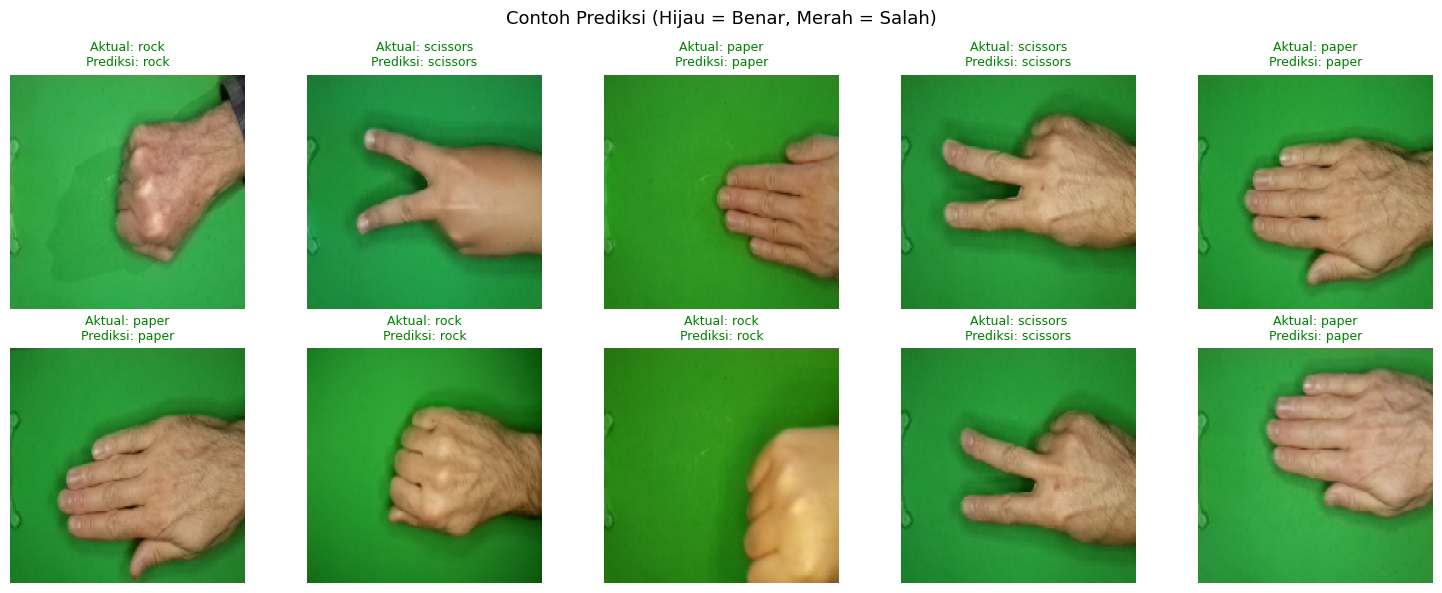

Contoh prediksi disimpan sebagai 'sample_predictions.png'


In [35]:
validation_generator.reset()
images, labels = next(validation_generator)
batch_preds = model.predict(images)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(images[i])
    true_label = class_names[np.argmax(labels[i])]
    pred_label = class_names[np.argmax(batch_preds[i])]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"Aktual: {true_label}\nPrediksi: {pred_label}", color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Contoh Prediksi (Hijau = Benar, Merah = Salah)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()
print("Contoh prediksi disimpan sebagai 'sample_predictions.png'")

**Sel 14: Fungsi Prediksi Gambar Tunggal**

Fungsi siap pakai untuk memprediksi satu gambar. Kamu hanya perlu memanggil predict_single_image('path_ke_gambar'). Model akan menampilkan gambar dan hasil prediksi beserta tingkat kepercayaannya.

In [36]:
def predict_single_image(image_path):
    """
    Memprediksi kelas rock/paper/scissors dari satu file gambar.
    """
    # Muat gambar, resize ke 150x150
    img = load_img(image_path, target_size=(150, 150))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediksi
    pred = model.predict(img_array)
    pred_label = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    # Tampilkan
    plt.figure(figsize=(4, 4))
    plt.imshow(load_img(image_path, target_size=(150, 150)))
    plt.title(f"Prediksi: {pred_label}\nKepercayaan: {confidence:.2f}%", fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Hasil Prediksi: {pred_label} (Kepercayaan: {confidence:.2f}%)")
    return pred_label